## 3. Linear regression


Thuật toán linear regression giải quyết các bài toán có đầu ra là giá trị thực, ví dụ: dự đoán giá nhà,
dự đoán giá cổ phiếu, dự đoán tuổi,...

### Bài toán
Bạn làm ở công ty bất động sản, bạn có dữ liệu về diện tích và giá nhà, giờ có một ngôi nhà mới
bạn muốn ước tính xem giá ngôi nhà đó khoảng bao nhiêu. Trên thực tế thì giá nhà phụ thuộc rất
nhiều yếu tố: diện tích, số phòng, gần trung tâm thương mại,.. nhưng để cho bài toán đơn giản giả
sử giá nhà chỉ phụ thuộc vào diện tích căn nhà. Bạn có dữ liệu về diện tích và giá bán của 30 căn
nhà như sau:


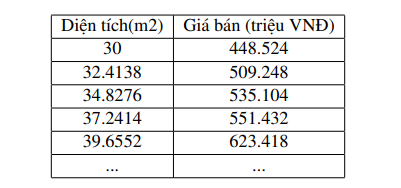

Khi có dữ liệu mình sẽ visualize dữ liệu lên hình 3.1
Nếu giờ yêu cầu bạn ước lượng nhà 50 mét vuông khoảng bao nhiêu tiền thì bạn sẽ làm thế nào? Vẽ
một đường thẳng gần với các điểm trên nhất và tính giá nhà ở điểm 50 như ở hình 3.2
Về mặt lập trình cũng cần làm 2 việc như vậy:
1. Training: Tìm đường thẳng (model) gần các điểm trên nhất. Mọi người có thể vẽ ngay được
đường thẳng mô tả dữ liệu từ hình 1, nhưng máy tính thì không, nó phải đi tìm bằng thuật
toán Gradient descent ở phía dưới. (Từ model và đường thẳng được dùng thay thế lẫn nhau
trong phần còn lại của bài này).
2. Prediction: Dự đoán xem giá của ngôi nhà 50 m
2
có giá bao nhiêu dựa trên đường tìm được ở
phần trên.

## Thiết lập công thức
### Model
### Cách đặt biến và mô hình hóa dữ liệu


Thay vì dùng ký hiệu $y = ax + b$ như hồi học cấp 3, trong Machine Learning, chúng ta thay đổi cách gọi tên một chút để sau này tính toán ma trận cho "mượt":

1. **Đổi tên các hệ số:**
   * Thay $a$ (hệ số góc) bằng $w_1$.
   * Thay $b$ (sai số/điểm cắt) bằng $w_0$.
   * Vậy phương trình đường thẳng sẽ là: **$y = w_1x + w_0$**
   * Công việc của chúng ta bây giờ là đi tìm bộ đôi $(w_0, w_1)$ sao cho khớp với dữ liệu nhất.

2. **Ký hiệu dữ liệu thực tế:**
   Ta gọi mỗi cặp dữ liệu (Diện tích, Giá nhà) là $(x_i, y_i)$.
   * Ví dụ: $(x_1, y_1) = (30, 448.524)$ là dữ liệu "thật" mà ta đã biết.

3. **Giá trị dự đoán (Prediction):**
   Với mỗi căn nhà có diện tích $x_i$, mô hình của chúng ta sẽ tính toán và đưa ra một cái giá dự đoán, ký hiệu là $\hat{y}_i$ (đọc là y-hat):
   $$\hat{y}_i = w_1x_i + w_0$$

**Tóm lại:** $y_i$ là giá trị "xịn" (Ground Truth), còn $\hat{y}_i$ là giá trị mà mô hình đang "đoán". Mục tiêu của mình là làm sao cho thằng đoán ($\hat{y}_i$) càng gần thằng thật ($y_i$) càng tốt!

### Loss function

Việc tìm $w_0, w_1$ bằng mắt thì có vẻ dễ, nhưng máy tính thì không thông minh như vậy. Ban đầu, nó chỉ biết chọn đại các giá trị ngẫu nhiên (ví dụ đặt luôn $w_0 = 0$ và $w_1 = 1$).

**Vấn đề thực tế:**
Thử nhìn vào đường thẳng $y = x$ (Hình 3.4). Đường này thực sự là một thảm họa vì nó quá xa so với các điểm dữ liệu thực tế:
* **Ví dụ:** Tại một căn nhà rộng $42 m^2$, thực tế người ta bán với giá **625 triệu** ($y = 625$).
* Thế nhưng, với cái model "ngây ngô" hiện tại ($y = 1 \times 42 + 0$), máy tính lại dự đoán căn nhà đó chỉ có giá **42 triệu** ($\hat{y} = 42$).

**Kết luận:** Sai số lúc này là cực lớn! Nhiệm vụ của chúng ta là phải tìm một cơ chế để bảo máy tính biết rằng nó đang sai rất nặng, từ đó nó phải tự điều chỉnh lại $w_0, w_1$ dần dần cho đến khi đường thẳng khớp với thực tế.

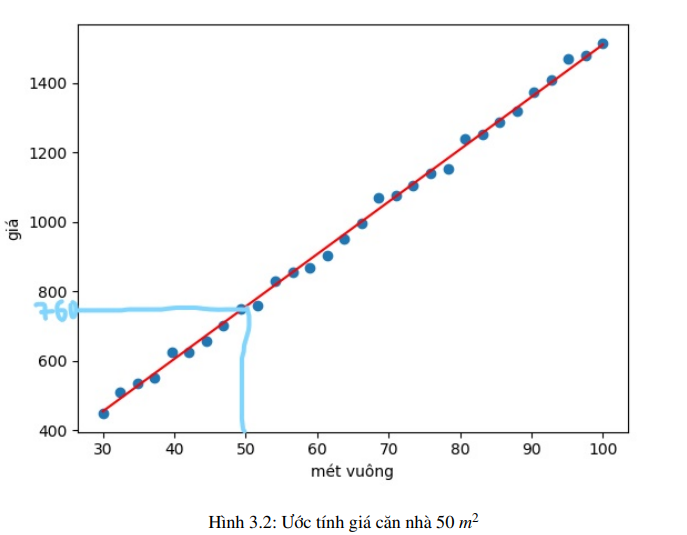

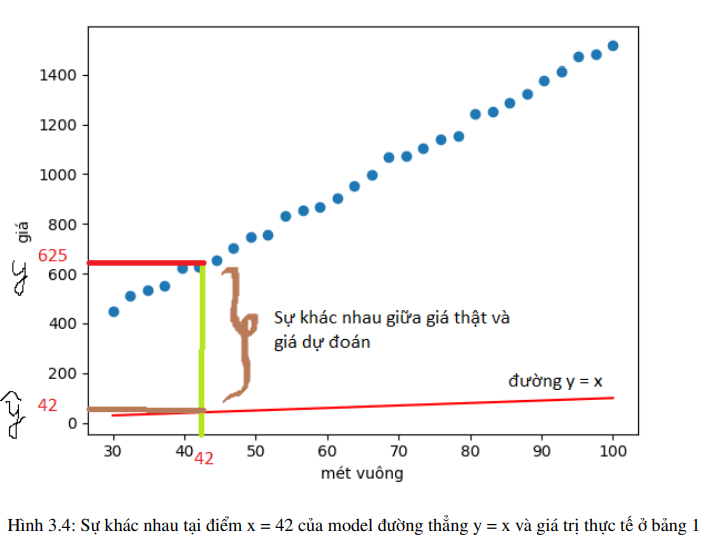

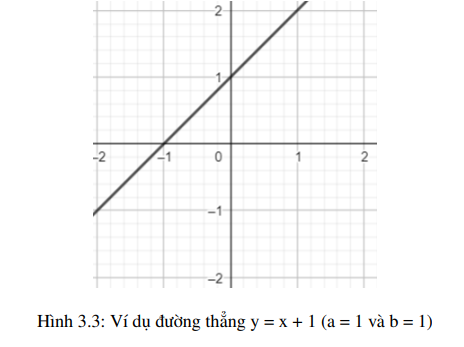



Để đánh giá bộ tham số $(w_0, w_1)$ hiện tại (ví dụ như bộ $(0, 1)$ lúc nãy), chúng ta cần một thước đo cụ thể. 

1. **Sai số tại từng điểm:**
   Với mỗi ngôi nhà $(x_i, y_i)$, độ chênh lệch giữa giá thật và giá dự đoán được tính bằng công thức: 
   $$\frac{1}{2}(\hat{y}_i - y_i)^2$$
   *(Tại sao lại bình phương? Để sai số luôn dương và triệt tiêu dấu trừ, còn số 1/2 là để sau này tính đạo hàm cho nó đẹp thôi).*

2. **Sai số trên toàn bộ dữ liệu (Hàm mất mát J):**
   Chúng ta lấy trung bình cộng sai số của tất cả $N$ ngôi nhà trong bảng dữ liệu:
   $$J = \frac{1}{2N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2$$

**Vài nhận xét quan trọng về J:**
* **J không bao giờ âm:** Vì nó là tổng của các bình phương.
* **J càng nhỏ càng tốt:** J càng bé chứng tỏ đường thẳng của mình càng bám sát các điểm dữ liệu. Nếu $J = 0$, chúc mừng, đường thẳng đi qua chính xác tất cả các điểm!

**Chốt lại:** Cái $J$ này được gọi là **Loss Function** (Hàm mất mát). Việc tìm ra đường thẳng "xịn" nhất bây giờ chỉ đơn giản là bài toán tối ưu: **Tìm $w_0, w_1$ sao cho giá trị $J$ nhỏ nhất có thể.**